# parallel worflow 
here we used the partial state update not normal state update . when we work on parallel then partial state need to pass when we work n the sequential workflow then we are using normal state update. both workflow we can use partial workflow

In [14]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict

In [15]:
# create state
class BatsmanState(TypedDict):
    
    # input
    runs: int
    balls: int
    fours : int
    sixes : int
    
    # calculate
    strike_rate: float
    boundary_percent : float
    ball_per_boundary: float
    
    #genrate
    summary: str

In [27]:
def calculate_sr( state: BatsmanState) -> BatsmanState:
    sr= (state['runs']/state['balls'])*100
    
    return {'strike_rate':sr}

In [17]:
def calculate_bp( state: BatsmanState) -> BatsmanState:
    bp = (((state['fours'] * 4) + (state['sixes'] * 6))/state['balls'])*100
   
    return {'boundary_percent':bp}

In [18]:
def calculate_bpb( state: BatsmanState) -> BatsmanState:
    bpb = state['balls']/(state['fours'] + state['sixes'])
    
    return {'ball_per_boundary':bpb}

In [23]:
def summary( state: BatsmanState):
    summary= f"""
    Strike Rate: {state['strike_rate']}\n
    boundary_percent: {state['boundary_percent']}\n
    ball_per_boundary: {state['ball_per_boundary']}
    
    """
    
   
    
    return {'summary':summary}

In [28]:
# create graph
graph = StateGraph(BatsmanState)

#create nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bp', calculate_bp)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary',summary)

# define edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bp')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bp', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

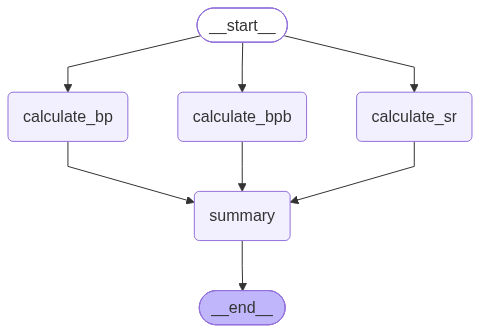

In [25]:
workflow

In [29]:
# execute workflow
initial_state ={
    'runs': 100,
    'balls': 50,
    'fours': 10,
    'sixes': 5,
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 200.0,
 'boundary_percent': 140.0,
 'ball_per_boundary': 3.3333333333333335,
 'summary': '\n    Strike Rate: 200.0\n\n    boundary_percent: 140.0\n\n    ball_per_boundary: 3.3333333333333335\n\n    '}